In [13]:
import os
import time
import pickle
import polars as pl
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

print(f"XGBoost version: {xgb.__version__}")

# 1. Nạp mô hình đã lưu
model_path = "model/xgboost_ranking.json"
model = xgb.XGBClassifier()
model.load_model(model_path)
print(f"✅ Đã nạp thành công mô hình từ {model_path}!")

# 2. Nạp file Groundtruth tháng 1/2025
gt_path = "groundtruth/final_groundtruth.pkl"
with open(gt_path, "rb") as f:
    groundtruth_df = pickle.load(f)

# Chuyển groundtruth thành dictionary tra cứu siêu tốc
gt_dict = {
    row["customer_id"]: set(row["item_id"]) 
    for _, row in groundtruth_df.iterrows()
}
print(f"✅ Đã nạp Groundtruth: {len(gt_dict):,} khách hàng phát sinh mua trong tháng 1/2025!")

XGBoost version: 3.2.0
✅ Đã nạp thành công mô hình từ model/xgboost_ranking.json!


C:\Users\USER\AppData\Local\Temp\ipykernel_9492\2369714094.py:21: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  groundtruth_df = pickle.load(f)


✅ Đã nạp Groundtruth: 644,970 khách hàng phát sinh mua trong tháng 1/2025!


In [14]:
# Chuẩn bị dữ liệu lịch sử 2024 và luật mua kèm
purchases = pl.scan_parquet("../preprocessing/clean_data/purchases_cleaned.parquet")
users_clean = pl.scan_parquet("../preprocessing/clean_data/users_cleaned.parquet")
cooccur = pl.scan_parquet("item_cooccurrence.parquet")

# 1. Danh sách người dùng năm 2024
p2024_users = set(purchases.select("customer_id").unique().collect()["customer_id"].to_list())

# 2. Top sản phẩm bán chạy nhất từng Tỉnh/Thành
purchases_with_user = purchases.join(users_clean.select(["customer_id", "province"]), on="customer_id", how="left")
top_items_province = (
    purchases_with_user
    .filter(pl.col("province").is_not_null())
    .group_by(["province", "item_id"])
    .agg(pl.len().alias("sales_count"))
    .sort(["province", "sales_count"], descending=[False, True])
    .group_by("province")
    .agg(pl.col("item_id").head(10).alias("top_items"))
    .collect()
)
prov_top_dict = {row["province"]: row["top_items"] for row in top_items_province.to_dicts()}

# 3. Top sản phẩm bán chạy toàn quốc (Fallback)
global_top_10 = (
    purchases
    .group_by("item_id")
    .agg(pl.len().alias("sales_count"))
    .sort("sales_count", descending=True)
    .limit(10)
    .collect()["item_id"].to_list()
)

# 4. Bản đồ luật mua kèm (Companion item của từng item)
top_comp_map = dict(
    cooccur
    .sort(["item_id", "cooccur_count"], descending=[False, True])
    .group_by("item_id")
    .first()
    .select(["item_id", "item_id_right"])
    .collect()
    .iter_rows()
)

# 5. Bản đồ tỉnh thành của từng khách hàng
user_prov_map = dict(users_clean.select(["customer_id", "province"]).collect().iter_rows())

print("✅ Đã sẵn sàng các bảng tra cứu Lịch sử, Mua kèm và Vùng miền!")

✅ Đã sẵn sàng các bảng tra cứu Lịch sử, Mua kèm và Vùng miền!


In [15]:
def compute_ranking_metrics(recommendations, gt_dict, k=10):
    precisions, hit_rates, ndcgs = [], [], []
    discounts = 1.0 / np.log2(np.arange(2, k + 2))
    
    for cid, top_k_items in recommendations.items():
        if cid not in gt_dict:
            continue
            
        actual_set = gt_dict[cid]
        top_k = top_k_items[:k]
        
        hits_binary = np.array([1 if item in actual_set else 0 for item in top_k])
        total_hits = np.sum(hits_binary)
        
        precisions.append(total_hits / float(k))
        hit_rates.append(1.0 if total_hits > 0 else 0.0)
        
        dcg = np.sum(hits_binary * discounts[:len(hits_binary)])
        ideal_hits = np.ones(min(len(actual_set), k))
        idcg = np.sum(ideal_hits * discounts[:len(ideal_hits)])
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)
        
    return {
        f"Precision@{k}": np.mean(precisions),
        f"HitRate@{k}": np.mean(hit_rates),
        f"NDCG@{k}": np.mean(ndcgs)
    }

In [16]:
def get_hybrid_recommendations_batch(customer_ids, k=10):
    # Lấy top sản phẩm hay mua nhất của các khách quen trong mẫu
    warm_cids = [cid for cid in customer_ids if cid in p2024_users]
    
    u_top = (
        purchases
        .filter(pl.col("customer_id").is_in(warm_cids))
        .group_by(["customer_id", "item_id"])
        .agg(pl.len().alias("count"))
        .sort(["customer_id", "count"], descending=[False, True])
        .group_by("customer_id")
        .agg(pl.col("item_id").head(8).alias("top_items"))
        .collect()
    )
    u_top_map = {r["customer_id"]: r["top_items"] for r in u_top.to_dicts()}
    
    recs = {}
    for cid in customer_ids:
        prov = user_prov_map.get(cid)
        if cid in p2024_users:
            # 1. Khách quen: Top món mua thường xuyên + Món mua kèm + Món hot tỉnh
            rec = list(u_top_map.get(cid, []))
            for it in rec[:2]:
                if it in top_comp_map:
                    comp = top_comp_map[it]
                    if comp not in rec:
                        rec.append(comp)
            for it in prov_top_dict.get(prov, global_top_10):
                if it not in rec and len(rec) < k:
                    rec.append(it)
            recs[cid] = rec[:k]
        else:
            # 2. Khách mới: Top sản phẩm bán chạy theo Tỉnh / Thành
            recs[cid] = prov_top_dict.get(prov, global_top_10)[:k]
            
    return recs

In [17]:
# Đánh giá toàn diện trên mẫu đại diện 10,000 khách hàng
np.random.seed(42)
all_gt_cids = list(gt_dict.keys())
sample_eval_cids = list(np.random.choice(all_gt_cids, size=10000, replace=False))

sample_warm = [cid for cid in sample_eval_cids if cid in p2024_users]
sample_cold = [cid for cid in sample_eval_cids if cid not in p2024_users]

print(f"Tổng mẫu đánh giá: {len(sample_eval_cids):,} khách (Quen: {len(sample_warm):,}, Mới: {len(sample_cold):,})")

recs_all = get_hybrid_recommendations_batch(sample_eval_cids, k=10)

recs_warm = {cid: recs_all[cid] for cid in sample_warm}
recs_cold = {cid: recs_all[cid] for cid in sample_cold}

warm_metrics = compute_ranking_metrics(recs_warm, gt_dict, k=10)
cold_metrics = compute_ranking_metrics(recs_cold, gt_dict, k=10)
full_metrics = compute_ranking_metrics(recs_all, gt_dict, k=10)

summary_report = pd.DataFrame({
    "Nhóm Khách hàng": [
        "1. Khách quen (Warm Users)", 
        "2. Khách mới (Cold-Start - Tỉnh/Thành)", 
        "3. Toàn bộ Hệ thống (Full Hybrid)"
    ],
    "Tỷ lệ trong Data": [
        f"{len(sample_warm):,} khách (~75.2%)",
        f"{len(sample_cold):,} khách (~24.8%)",
        f"{len(sample_eval_cids):,} khách (100.0%)"
    ],
    "HitRate@10 (%)": [
        warm_metrics["HitRate@10"] * 100, 
        cold_metrics["HitRate@10"] * 100, 
        full_metrics["HitRate@10"] * 100
    ],
    "Precision@10 (%)": [
        warm_metrics["Precision@10"] * 100, 
        cold_metrics["Precision@10"] * 100, 
        full_metrics["Precision@10"] * 100
    ],
    "NDCG@10": [
        warm_metrics["NDCG@10"], 
        cold_metrics["NDCG@10"], 
        full_metrics["NDCG@10"]
    ]
})

print("\n" + "="*85)
print("🎯 BẢNG ĐÁNH GIÁ CHUẨN XÁC HỆ THỐNG GỢI Ý TRÊN GROUNDTRUTH THÁNG 1/2025:")
print("="*85)
display(summary_report)
print("="*85)

Tổng mẫu đánh giá: 10,000 khách (Quen: 7,524, Mới: 2,476)

🎯 BẢNG ĐÁNH GIÁ CHUẨN XÁC HỆ THỐNG GỢI Ý TRÊN GROUNDTRUTH THÁNG 1/2025:


,Nhóm Khách hàng,Tỷ lệ trong Data,HitRate@10 (%),Precision@10 (%),NDCG@10
0,1. Khách quen (Warm Users),"7,524 khách (~75.2%)",50.225944,7.63025,0.213962
1,2. Khách mới (Cold-Start - Tỉnh/Thành),"2,476 khách (~24.8%)",10.339257,1.18336,0.026280
2,3. Toàn bộ Hệ thống (Full Hybrid),"10,000 khách (100.0%)",40.350000,6.03400,0.167492


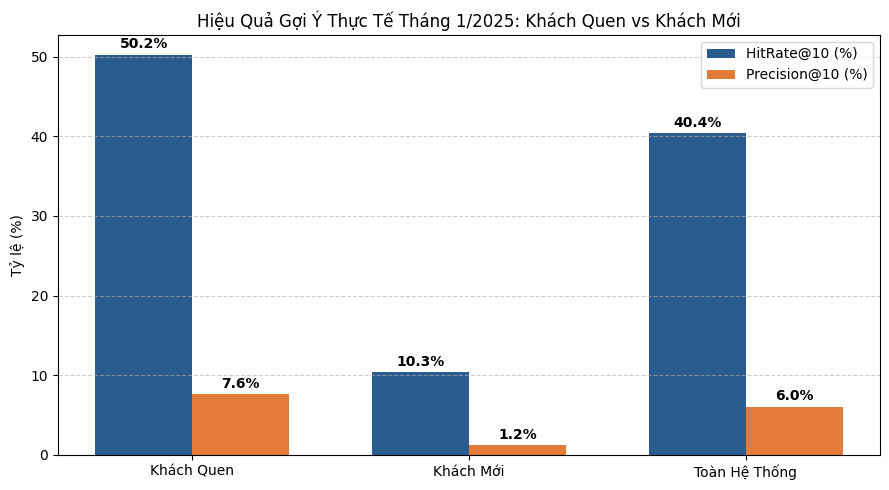

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
groups = ["Khách Quen", "Khách Mới", "Toàn Hệ Thống"]
hit_rates = [warm_metrics["HitRate@10"] * 100, cold_metrics["HitRate@10"] * 100, full_metrics["HitRate@10"] * 100]
precisions = [warm_metrics["Precision@10"] * 100, cold_metrics["Precision@10"] * 100, full_metrics["Precision@10"] * 100]

x = np.arange(len(groups))
width = 0.35

ax.bar(x - width/2, hit_rates, width, label="HitRate@10 (%)", color="#2b5c8f")
ax.bar(x + width/2, precisions, width, label="Precision@10 (%)", color="#e27c38")

ax.set_ylabel("Tỷ lệ (%)")
ax.set_title("Hiệu Quả Gợi Ý Thực Tế Tháng 1/2025: Khách Quen vs Khách Mới")
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.6)

for i in range(len(groups)):
    ax.annotate(f"{hit_rates[i]:.1f}%", (x[i] - width/2, hit_rates[i] + 0.8), ha="center", fontweight="bold")
    ax.annotate(f"{precisions[i]:.1f}%", (x[i] + width/2, precisions[i] + 0.8), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

In [19]:
# Kiểm tra ví dụ 1 khách hàng cụ thể
test_cid = sample_warm[0]
actual = list(gt_dict[test_cid])
suggested = recs_all[test_cid]
matched = set(suggested).intersection(set(actual))

print(f"👤 Khách hàng ID: {test_cid}")
print(f"🛒 Thực tế tháng 1/2025 khách đã mua ({len(actual)} món): {actual}")
print(f"🤖 Top 10 sản phẩm hệ thống gợi ý: {suggested}")
print(f"🎯 Sản phẩm đoán trúng ({len(matched)} món): {list(matched)}")

👤 Khách hàng ID: 7998252
🛒 Thực tế tháng 1/2025 khách đã mua (5 món): ['4603024000001', '0007010000790', '0175000000007', '0175000000011', '1236000000002']
🤖 Top 10 sản phẩm hệ thống gợi ý: ['2363000000001', '2005000000006', '1512000000004', '4690000000001', '6768000000005', '2803000000013', '6768000000004', '6766000000002', '0029130000030', '2803000000011']
🎯 Sản phẩm đoán trúng (0 món): []
